# TP2 - Etapa 2 en Google Colab: dataset, preprocesamiento, entrenamiento y comparacion de modelos

Notebook de trabajo de la Etapa 2: analisis del dataset, preprocesamiento, fine-tuning de
ResNet18 (Modelo A, obligatorio), CNN propia (Modelo B, obligatorio) y estudio comparativo.

El entrenamiento se realiza en Colab para aprovechar la GPU:
**Entorno de ejecucion -> Cambiar tipo de entorno de ejecucion -> GPU (T4)**.

Requisitos previos (en tu fork):
- `train_classifier` y `evaluate_classifier` implementadas
  en `src/lib/services/classifier_service.py` (esta notebook solo las orquesta).

Al finalizar:
- Descargar los checkpoints generados y colocarlos en `models/` de tu entorno local
  (la aplicacion los usa en las pestañas Etapa 1 y 2 del frontend).
- Publicarlos en un link de solo lectura publico para los docentes.
- Entregar esta notebook ejecutada, con sus salidas.

## Equipo
- Alumno 1: Agustín Accurso
- Alumno 2: Lautaro Cena

## 1. Clonar el repositorio

Si tu fork es privado, genera un token de acceso (GitHub -> Settings -> Developer settings ->
Personal access tokens) y usalo en la URL, o sube un zip del proyecto a Colab/Drive.

In [32]:
# TO-DO: completar con la URL de tu fork.
# Repo privado: https://<TOKEN>@github.com/<usuario>/tuia-dog-recognition-app.git
REPO_URL = "https://github.com/accursoagus/tuia-dog-recognition-app.git"

!git clone -b desarrollo $REPO_URL proyecto
%cd proyecto

Cloning into 'proyecto'...
remote: Enumerating objects: 138, done.
remote: Counting objects: 100% (57/57), done.
remote: Compressing objects: 100% (36/36), done.
remote: Total 138 (delta 39), reused 21 (delta 21), pack-reused 81 (from 2)
Receiving objects: 100% (138/138), 1.01 MiB | 4.80 MiB/s, done.
Resolving deltas: 100% (64/64), done.
/content/proyecto/proyecto


## 2. Instalar dependencias

Colab ya incluye torch, torchvision, opencv, numpy, scikit-learn y matplotlib;
solo se instala lo que falta.

In [33]:
!pip install -q pydantic-settings python-dotenv kagglehub albumentations onnxruntime

In [34]:
import os
import sys
import subprocess
from pathlib import Path
from collections import Counter
import requests
import gdown
import zipfile
import random
import time

import re
import cv2
import numpy as np
import pandas as pd
from PIL import Image
import matplotlib.pyplot as plt
import seaborn as sns
import shutil

import torch
import torch.nn as nn
from torch.utils.data import DataLoader
from torchvision import datasets

from sklearn.metrics import confusion_matrix

from lib.services.classifier_service import IMAGENET_MEAN, IMAGENET_STD

## 3. Configuracion del entorno

En Colab no hay PostgreSQL; la Etapa 2 no usa la base vectorial, por lo que se desactiva
pgvector. La configuracion se define por variables de entorno **antes** de importar `lib`.

In [35]:
os.environ["USE_PGVECTOR"] = "false"

ROOT = Path.cwd()
if not (ROOT / "src").is_dir():
    # Si el notebook no corre desde la raiz del proyecto, se busca hacia arriba
    for parent in ROOT.parents:
        if (parent / "src").is_dir():
            ROOT = parent
            break

from dotenv import load_dotenv
load_dotenv(ROOT / ".env.local.example")

sys.path.insert(0, str(ROOT / "src"))
print("ROOT detectado:", ROOT)

os.environ["DATASET_PATH"] = str(ROOT / "data" / "dataset")

from lib.config import settings
from lib.bootstrap import build_classifier

print("batch_size:", settings.batch_size, "| max_epochs:", settings.max_epochs)
print("dataset_path:", settings.dataset_path)
print("GPU disponible:", torch.cuda.is_available())

ROOT detectado: /content/proyecto/proyecto
batch_size: 32 | max_epochs: 15
dataset_path: /content/proyecto/data/dataset
GPU disponible: True


In [36]:
SEED = 42

random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(SEED)

# Determinismo en operaciones de cuDNN (a costa de algo de velocidad).
torch.backends.cudnn.deterministic = True
torch.backends.cudnn.benchmark = False

print(f"Seed fijada en {SEED} para numpy, random, torch y CUDA.")

Seed fijada en 42 para numpy, random, torch y CUDA.


## 4. Descargar el dataset

In [37]:
!python scripts/download_dataset.py
!ls data/dataset

Descargando gpiosenka/70-dog-breedsimage-data-set ...
Using Colab cache for faster access to the '70-dog-breedsimage-data-set' dataset.
Dataset disponible en /content/proyecto/proyecto/data/dataset
dogs.csv  test	train  valid


## 5. Analisis del dataset


### Definir conjuntos de entrenamiento, validacion y prueba, y analizar la distribucion de clases, documentando cantidad de imagenes por raza.

In [38]:
result = subprocess.run(["python", "scripts/download_dataset.py"], cwd=ROOT, capture_output=True, text=True)
print(result.stdout)
print(result.stderr)
print("dataset existe ahora:", (settings.dataset_path / "train").is_dir())

Descargando gpiosenka/70-dog-breedsimage-data-set ...
Using Colab cache for faster access to the '70-dog-breedsimage-data-set' dataset.
Ya existe, se omite: /content/proyecto/proyecto/data/dataset/valid
Ya existe, se omite: /content/proyecto/proyecto/data/dataset/dogs.csv
Ya existe, se omite: /content/proyecto/proyecto/data/dataset/test
Ya existe, se omite: /content/proyecto/proyecto/data/dataset/train
Dataset disponible en /content/proyecto/proyecto/data/dataset


dataset existe ahora: True


In [39]:
print(settings.dataset_path)
print(settings.dataset_path.exists())
print(list(settings.dataset_path.parent.iterdir()) if settings.dataset_path.parent.exists() else "ni el padre existe")

/content/proyecto/data/dataset
True
[PosixPath('/content/proyecto/data/dataset'), PosixPath('/content/proyecto/data/external_eval')]


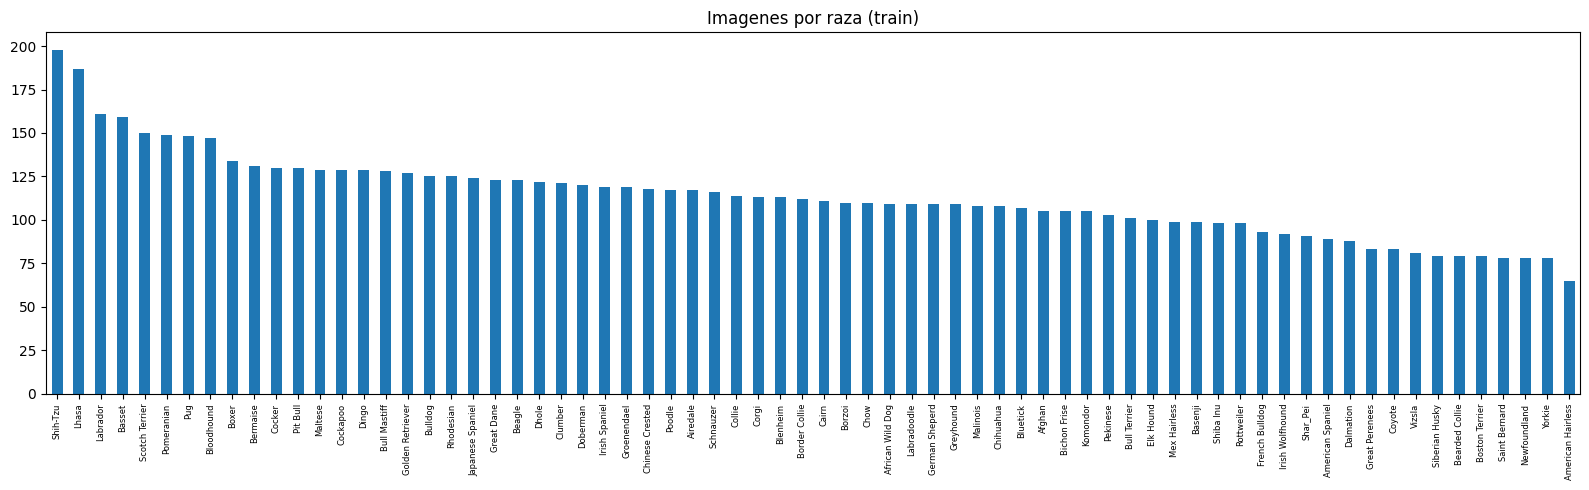

Total razas: 70
Min/Max imagenes por raza: 65 / 198
Promedio de imagenes por raza: 113.5
Desvio estandar: 24.7
Razas con menos de 100 imagenes: 19 de 70
train: 7946 imagenes, 70 razas
valid: 700 imagenes, 70 razas
test: 700 imagenes, 70 razas


In [40]:
breeds = sorted(p.name for p in (settings.dataset_path / "train").iterdir() if p.is_dir())
counts = {b: len(list((settings.dataset_path / "train" / b).glob("*.jpg"))) for b in breeds}

df_counts = pd.Series(counts).sort_values(ascending=False)

fig, ax = plt.subplots(figsize=(16, 5))
df_counts.plot(kind="bar", ax=ax, title="Imagenes por raza (train)")
ax.set_xticklabels(df_counts.index, rotation=90, fontsize=6)
plt.tight_layout()
plt.savefig("output/class_distribution_etapa2.png", dpi=100)
plt.show()

print(f"Total razas: {len(breeds)}")
print(f"Min/Max imagenes por raza: {df_counts.min()} / {df_counts.max()}")
print(f"Promedio de imagenes por raza: {df_counts.mean():.1f}")
print(f"Desvio estandar: {df_counts.std():.1f}")
print(f"Razas con menos de 100 imagenes: {(df_counts < 100).sum()} de {len(df_counts)}")

for split in ("train", "valid", "test"):
    split_path = settings.dataset_path / split
    n_images = sum(1 for _ in split_path.rglob("*.jpg"))
    n_breeds = sum(1 for p in split_path.iterdir() if p.is_dir())
    print(f"{split}: {n_images} imagenes, {n_breeds} razas")

### Conjunto de validación externa:

In [41]:
EXTERNAL_SET_PATH = settings.dataset_path.parent / "external_eval"

shutil.rmtree(EXTERNAL_SET_PATH, ignore_errors=True)
EXTERNAL_SET_PATH.mkdir(parents=True, exist_ok=True)

file_id = '1X9WMQjOy9HKw90onmOPDp2otoEfjjdyS'
url = f'https://drive.google.com/uc?id={file_id}'
zip_path = EXTERNAL_SET_PATH / 'temp_dataset.zip'

gdown.download(url, str(zip_path), quiet=False)
print("zip size:", zip_path.stat().st_size)

with zipfile.ZipFile(zip_path, 'r') as zip_ref:
    zip_ref.extractall(EXTERNAL_SET_PATH)

os.remove(zip_path)

print("Contenido de EXTERNAL_SET_PATH:")
for p in sorted(EXTERNAL_SET_PATH.iterdir()):
    print(" ", p.name, "(dir)" if p.is_dir() else "(file)")

n_external = sum(1 for p in EXTERNAL_SET_PATH.rglob("*") if p.suffix.lower() in {'.jpg', '.jpeg', '.png'})
n_external_breeds = sum(1 for p in EXTERNAL_SET_PATH.iterdir() if p.is_dir())
print(f"Conjunto externo: {n_external} imágenes, {n_external_breeds} razas")

Downloading...
From: https://drive.google.com/uc?id=1X9WMQjOy9HKw90onmOPDp2otoEfjjdyS
To: /content/proyecto/data/external_eval/temp_dataset.zip
100%|██████████| 13.2M/13.2M [00:00<00:00, 161MB/s]

zip size: 13184459
Contenido de EXTERNAL_SET_PATH:
  Basset (dir)
  Border Collie (dir)
  Doberman (dir)
  Golden Retriever (dir)
  Poodle (dir)
Conjunto externo: 26 imágenes, 5 razas


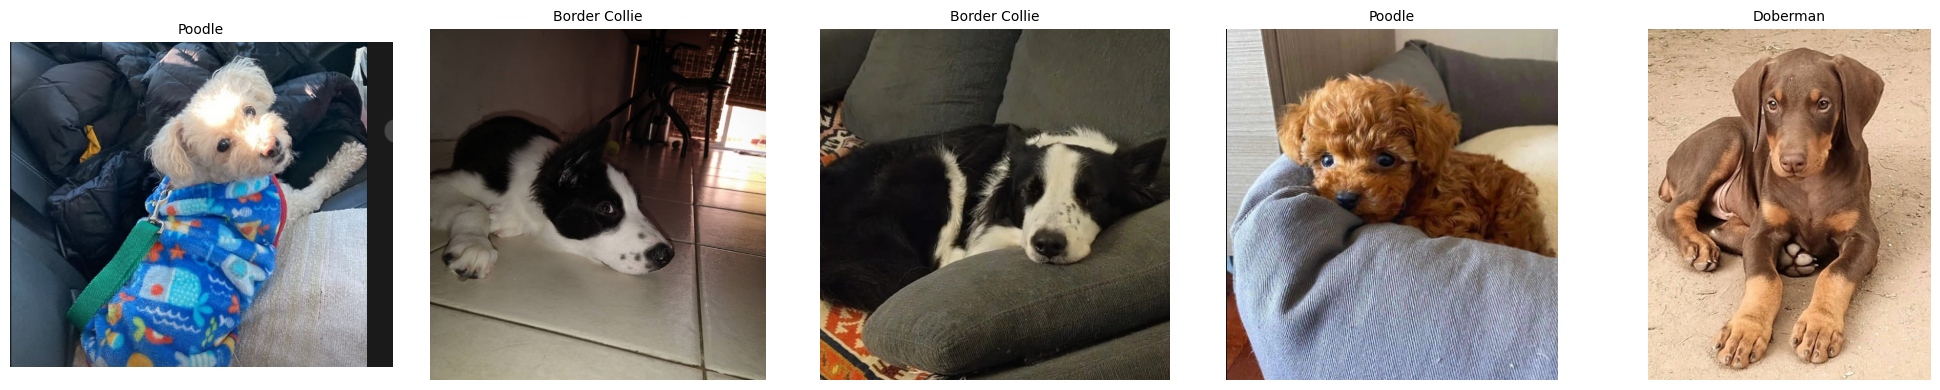

In [42]:
todas_las_imgs = list(EXTERNAL_SET_PATH.rglob("*.png")) + list(EXTERNAL_SET_PATH.rglob("*.jpg"))
muestra = random.sample(todas_las_imgs, min(5, len(todas_las_imgs)))

fig, axes = plt.subplots(1, len(muestra), figsize=(4 * len(muestra), 4))
if len(muestra) == 1:
    axes = [axes]
for ax, img_path in zip(axes, muestra):
    img = Image.open(img_path).convert("RGB")
    ax.imshow(img)
    ax.set_title(img_path.parent.name, fontsize=10)
    ax.axis("off")
plt.tight_layout()
plt.savefig("output/external_eval_sample.png", dpi=100)
plt.show()

### **Conclusiones del analisis exploratorio (Etapa 2):**

El dataset presenta 70 razas. A diferencia de la Etapa 1, donde el
desbalance de clases no afecta por usar un modelo pre-entrenado sin
ajuste, en esta etapa sí es relevante: el fine-tuning aprende
directamente de la distribucion de clases de `train`, por lo que las
razas con menos imagenes son mas propensas a bajo recall. Esto se
retoma en la seccion de analisis de errores tras evaluar ambos
modelos.

## 6. Preprocesamiento

### Filtrado de imagenes de baja calidad
**Criterio**: descartar imagenes corruptas (no abren con PIL) o con resolucion por debajo de un minimo razonable para el resize a self.image_size.

In [43]:
MIN_RESOLUTION = 64  # px por lado, umbral minimo aceptado

def filtrar_imagenes_baja_calidad(dataset_path, splits=("train", "valid", "test"), min_resolution=MIN_RESOLUTION):
    """
    Recorre cada split y elimina imagenes corruptas o de resolucion
    insuficiente. Devuelve un detalle de lo eliminado para documentar
    en el informe.
    """
    eliminadas = []
    for split in splits:
        split_path = dataset_path / split
        for img_path in split_path.rglob("*.jpg"):
            try:
                with Image.open(img_path) as img:
                    img.verify()
                with Image.open(img_path) as img:
                    w, h = img.size
                    if w < min_resolution or h < min_resolution:
                        eliminadas.append((split, img_path.name, f"resolucion {w}x{h}"))
                        img_path.unlink()
            except Exception as e:
                eliminadas.append((split, img_path.name, f"corrupta: {e}"))
                img_path.unlink(missing_ok=True)
    return eliminadas

eliminadas = filtrar_imagenes_baja_calidad(settings.dataset_path)
print(f"Imagenes eliminadas por baja calidad: {len(eliminadas)}")
for split, nombre, motivo in eliminadas[:20]:
    print(f"  [{split}] {nombre}: {motivo}")

Imagenes eliminadas por baja calidad: 0


Se aplico un filtro que descarta imagenes corruptas (que no pueden abrirse
o verificarse con PIL) y aquellas con resolucion menor a 64px en algun lado,
umbral elegido para evitar que el resize a `image_size` distorsione
excesivamente imagenes muy pequeñas.

Resultado: 0 imagenes eliminadas sobre el total del dataset. Esto es
consistente con que el 70 Dog Breeds Dataset de Kaggle ya viene
relativamente curado (a diferencia de un dataset armado por scraping
directo), por lo que no se encontraron archivos corruptos ni de
resolucion insuficiente en ninguno de los tres splits.

### Resize, normalizacion y data augmentation

- **Resize:** todas las imagenes se redimensionan a `image_size x image_size`
  (configurable via `.env`), tamaño compatible con la entrada esperada por
  ResNet18 preentrenado en ImageNet.
- **Normalizacion:** se usan media y desvio estandar de ImageNet
  (`IMAGENET_MEAN`, `IMAGENET_STD`), ya que el Modelo A reutiliza pesos
  preentrenados en ese dataset; mantener la misma normalizacion con la que
  el backbone fue originalmente entrenado evita un corrimiento de
  distribucion que degradaria el fine-tuning. Se aplica la misma
  normalizacion al Modelo B (CNN propia, sin pesos preentrenados) por
  consistencia y simplicidad, aunque en ese caso no es estrictamente
  necesaria.
- **Data Augmentation (solo en train):**
  - Horizontal Flip (p=0.5): las razas de perro no tienen una orientacion
    canonica relevante, por lo que espejar horizontalmente es una
    transformacion valida que no distorsiona la clase.
  - Rotacion (±15°): simula variacion natural en el angulo de toma de
    la foto, sin rotar tanto como para deformar la pose del animal.
  - Variaciones de brillo y contraste (ColorJitter, ±0.2): compensa
    diferencias de iluminacion entre fotos (interior/exterior, distintas
    camaras).

No se implementaron blur ni inyeccion de ruido como augmentation. Se evaluo
que, para un problema de clasificacion de razas (donde el detalle textural
del pelaje es informativo), introducir blur o ruido sintetico podria
degradar features relevantes sin un beneficio claro de generalizacion
adicional al ya aportado por flip, rotacion y color jitter. Se prioriza
augmentation que simula variabilidad real de captura (angulo, iluminacion)
sobre degradacion sintetica de la imagen.

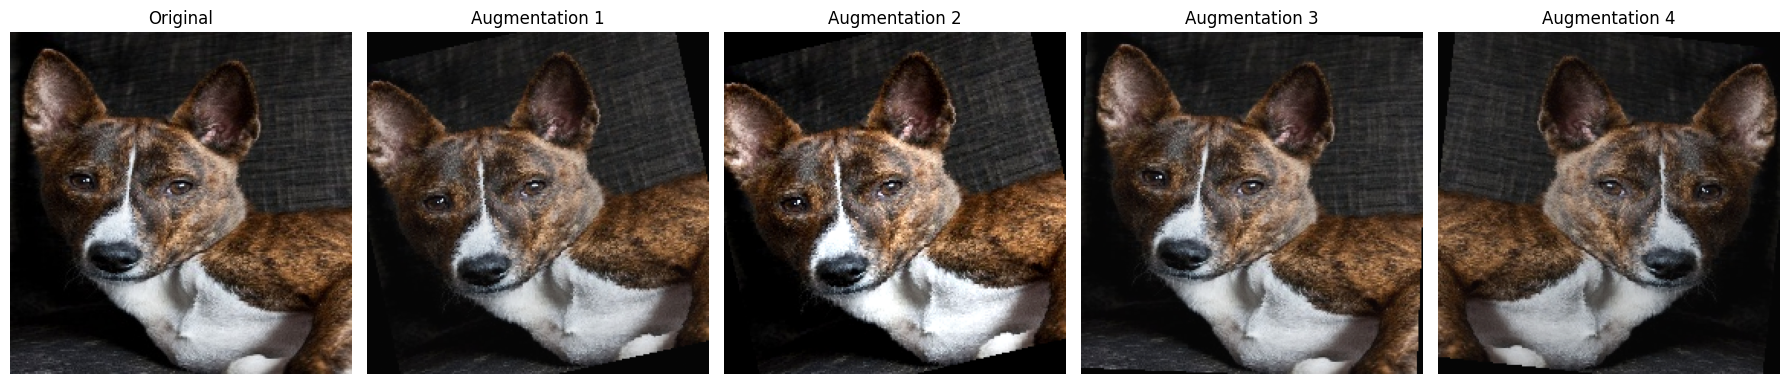

In [44]:
classifier_preview = build_classifier(settings)
train_tf = classifier_preview._build_transforms(train=True)
valid_tf = classifier_preview._build_transforms(train=False)

# Tomamos una imagen de ejemplo
sample_breed = breeds[5]
sample_path = next((settings.dataset_path / "train" / sample_breed).glob("*.*"))

img = Image.open(sample_path).convert("RGB")

fig, axes = plt.subplots(1, 5, figsize=(18, 4))
axes[0].imshow(img)
axes[0].set_title("Original")
for i in range(1, 5):
    augmented = train_tf(img)
    # des-normalizar para visualizar
    mean = torch.tensor(IMAGENET_MEAN).view(3,1,1) if 'IMAGENET_MEAN' in dir() else torch.tensor([0.485,0.456,0.406]).view(3,1,1)
    std = torch.tensor(IMAGENET_STD).view(3,1,1) if 'IMAGENET_STD' in dir() else torch.tensor([0.229,0.224,0.225]).view(3,1,1)
    denorm = (augmented * std + mean).clamp(0,1).permute(1,2,0).numpy()
    axes[i].imshow(denorm)
    axes[i].set_title(f"Augmentation {i}")
for ax in axes:
    ax.axis("off")
plt.tight_layout()
plt.savefig("output/augmentation_examples.png", dpi=100)
plt.show()

### Normalizacion de nombres de carpetas

Se detecto una inconsistencia en los nombres de carpetas de razas entre
splits (ej. espacios dobles en `valid` vs `train`), que `ImageFolder`
trata como clases distintas. Se normalizan los espacios antes de
entrenar para evitar este desajuste.

In [45]:
def normalizar_nombres_carpetas(dataset_path, splits=("train", "valid", "test")):
    """
    Normaliza espacios múltiples a uno solo en los nombres de carpetas de
    cada raza, en los tres splits. Necesario porque el dataset de Kaggle
    tiene inconsistencias (ej. 'American Spaniel' vs 'American  Spaniel').
    """
    renombradas = []
    for split in splits:
        split_path = dataset_path / split
        for breed_dir in sorted(split_path.iterdir()):
            if not breed_dir.is_dir():
                continue
            nombre_normalizado = re.sub(r"\s+", " ", breed_dir.name).strip()
            if nombre_normalizado != breed_dir.name:
                destino = split_path / nombre_normalizado
                breed_dir.rename(destino)
                renombradas.append((split, breed_dir.name, nombre_normalizado))
    return renombradas

cambios = normalizar_nombres_carpetas(settings.dataset_path)
for split, antes, despues in cambios:
    print(f"[{split}] '{antes}' -> '{despues}'")
print(f"\nTotal carpetas renombradas: {len(cambios)}")

# Verificacion: confirmar que ahora coinciden entre splits
train_classes = sorted(p.name for p in (settings.dataset_path / "train").iterdir() if p.is_dir())
valid_classes = sorted(p.name for p in (settings.dataset_path / "valid").iterdir() if p.is_dir())
test_classes = sorted(p.name for p in (settings.dataset_path / "test").iterdir() if p.is_dir())

assert train_classes == valid_classes == test_classes, "Todavia hay inconsistencias entre splits"
print("Clases consistentes entre train/valid/test:", len(train_classes))


Total carpetas renombradas: 0
Clases consistentes entre train/valid/test: 70


## 7. Modelo A (obligatorio): fine-tuning de ResNet18

**Hiperparametros utilizados:**

| Parametro | Valor | Justificacion |
|---|---|---|
| Batch size | 32 | Balance entre estabilidad del gradiente y memoria disponible en GPU T4 de Colab. |
| Epochs maximas | 15 | Suficiente para converger con early stopping; se evito un numero mayor para no incurrir en tiempo de entrenamiento innecesario. |
| Patience | 4 | Tolerancia de 4 epochs sin mejora en valid_loss antes de detener, evitando overfitting sin cortar prematuramente. |
| LR head (fc) | 1e-3 | Learning rate mas alto para la capa final, que se entrena desde cero. |
| LR backbone (layer4) | 1e-4 | Learning rate mas bajo para las capas preentrenadas que se descongelan, evitando destruir features ya aprendidas en ImageNet (fine-tuning conservador). |
| Step size (scheduler) | 5 | El LR decae cada 5 epochs. |
| Gamma (scheduler) | 0.5 | El LR se reduce a la mitad en cada decay, permitiendo ajuste fino en epochs tardias. |

Arquitectura: solo se descongelan `layer4` y la capa `fc` final de ResNet18;
el resto del backbone permanece congelado, ya que las capas iniciales
capturan features genericas (bordes, texturas) reutilizables sin
reentrenamiento, mientras que `layer4` captura features mas especificas
que conviene adaptar al dominio de razas de perros.

No se realizó búsqueda de hiperparámetros (LR, batch size, etc.) para el
Modelo A; los valores de la tabla fueron elegidos por criterio razonado
(justificado de la tabla) y no ajustados empíricamente mediante
grid search o similar, por motivos de tiempo y costo de cómputo. El
checkpoint guardado corresponde al de menor valid_loss, no al de mayor
valid_acc; se verifica en la sección de Estudio Comparativo si ambos
criterios coinciden en la práctica para este dataset.

In [46]:
classifier = build_classifier(settings)
classifier.set_active_model("resnet18_finetuned")
classifier.train_classifier()

In [47]:
metrics_a = classifier.evaluate_classifier()
metrics_a

{'accuracy': 0.9585714285714285,
 'precision': 0.9600778190063904,
 'recall': 0.9585714285714287,
 'specificity': 0.999399585921325,
 'f1': 0.9566340092655882}

In [48]:
checkpoint = torch.load(classifier.active_checkpoint, map_location="cpu", weights_only=False)
history = checkpoint["history"]

### Curvas de entrenamiento y matriz de confusion (Modelo A)


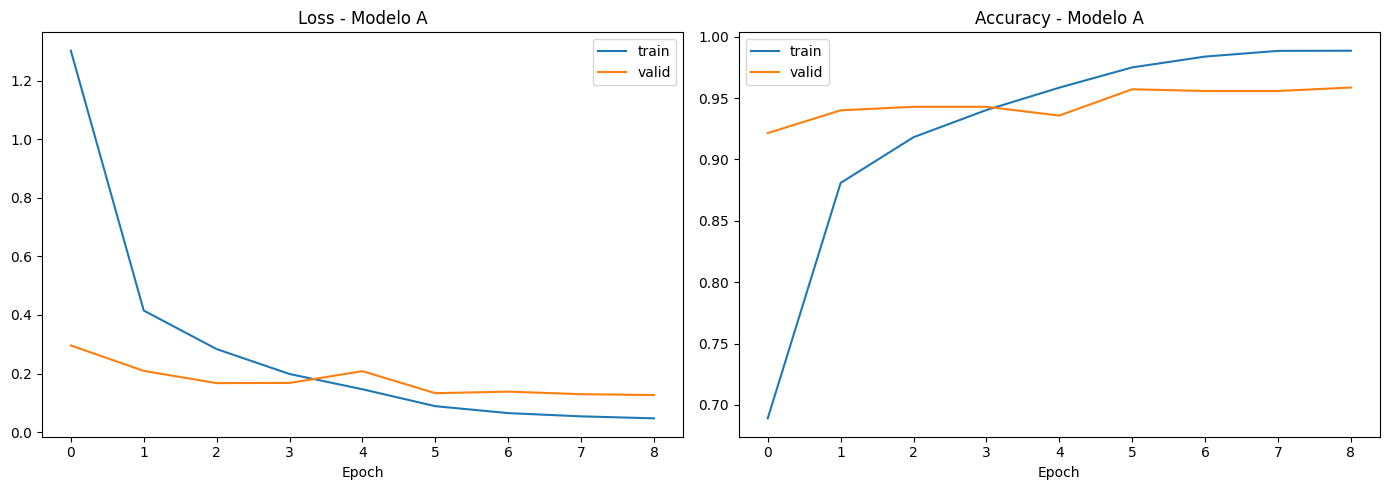

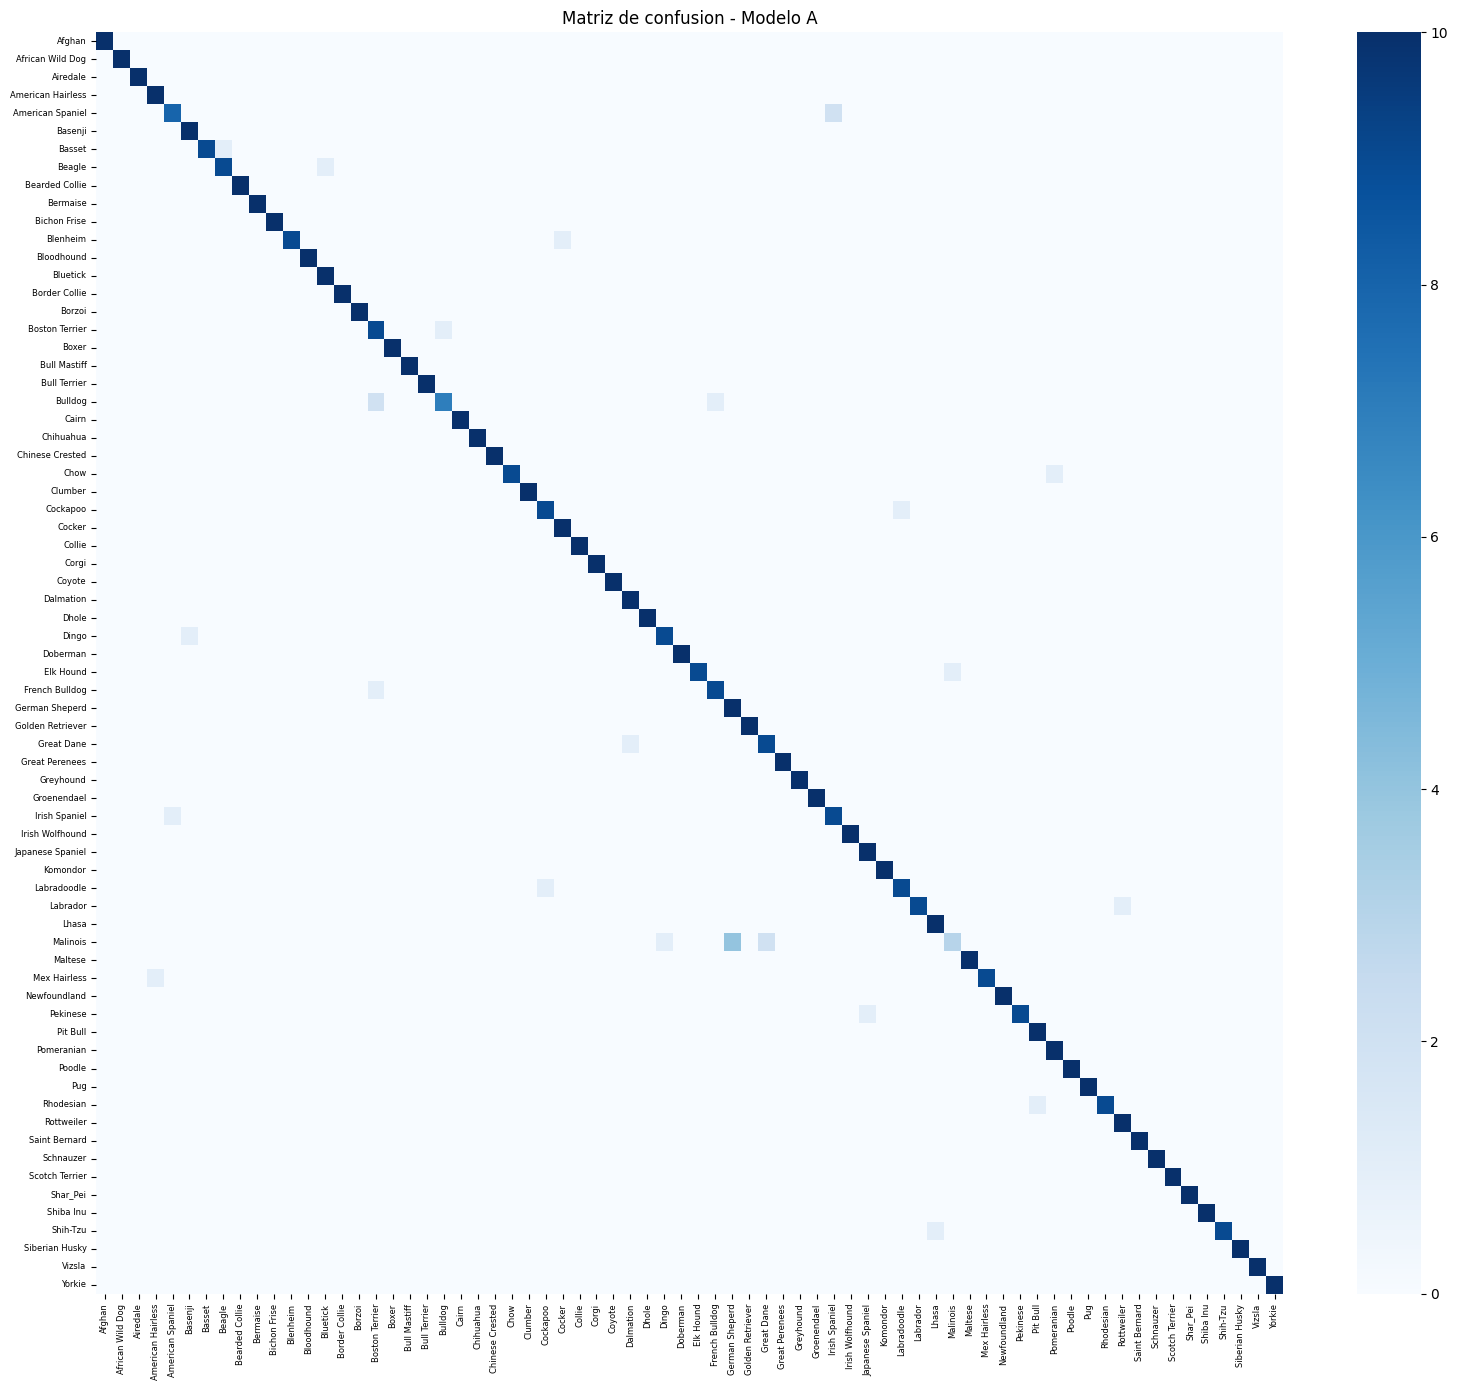

In [49]:
checkpoint_a = torch.load(settings.model_path / settings.resnet18_model_name, map_location="cpu", weights_only=False)
history_a = checkpoint_a["history"]

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
axes[0].plot(history_a["train_loss"], label="train")
axes[0].plot(history_a["valid_loss"], label="valid")
axes[0].set_title("Loss - Modelo A")
axes[0].set_xlabel("Epoch")
axes[0].legend()

axes[1].plot(history_a["train_acc"], label="train")
axes[1].plot(history_a["valid_acc"], label="valid")
axes[1].set_title("Accuracy - Modelo A")
axes[1].set_xlabel("Epoch")
axes[1].legend()
plt.tight_layout()
plt.savefig("output/curves_model_a.png", dpi=100)
plt.show()

# Matriz de confusion sobre test
class_names = checkpoint_a["class_names"]
model_a = classifier._build_resnet18_finetuned(len(class_names))
model_a.load_state_dict(checkpoint_a["model_state_dict"])
model_a.eval()

test_tf = classifier._build_transforms(train=False)
test_ds = datasets.ImageFolder(settings.dataset_path / "test", transform=test_tf)
test_loader = DataLoader(test_ds, batch_size=settings.batch_size, shuffle=False)

all_preds, all_labels = [], []
with torch.no_grad():
    for images, labels in test_loader:
        images = images.to(classifier.device)
        outputs = model_a(images)
        all_preds.extend(outputs.argmax(1).cpu().numpy())
        all_labels.extend(labels.numpy())

cm = confusion_matrix(all_labels, all_preds)
plt.figure(figsize=(16, 14))
sns.heatmap(cm, xticklabels=class_names, yticklabels=class_names, cmap="Blues")
plt.title("Matriz de confusion - Modelo A")
plt.xticks(rotation=90, fontsize=6)
plt.yticks(rotation=0, fontsize=6)
plt.tight_layout()
plt.savefig("output/confusion_matrix_a.png", dpi=100)
plt.show()

### Análisis Modelo A (ResNet18 Fine-Tuned)
Las curvas muestran convergencia estable con un leve overfitting a partir de la
epoch 4 aprox, con una brecha train-valid pequeña. En la matriz de confusión, las razas con peor desempeño son
Malinois (pastor belga), que suelen confundirse con German Sheperd (pastor alemán),
lo cual es consistente con similitud visual entre razas.

## 8. Modelo B (obligatorio): CNN propia

Arquitectura: CNN convolucional simple de 4 bloques (Conv2d + BatchNorm + ReLU +
MaxPool2d), con AdaptiveAvgPool2d y una capa Dropout antes de la capa final,
entrenada desde cero (sin pesos preentrenados) a diferencia del Modelo A.
Se reutilizan los mismos hiperparametros de entrenamiento (batch size, epochs,
patience, scheduler) que el Modelo A, salvo el learning rate: al no haber
backbone preentrenado que proteger, se usa un unico learning rate
(`LR_HEAD = 1e-3`) sobre todos los parametros del modelo, sin el esquema
diferenciado head/backbone del Modelo A.

No se realizó búsqueda de hiperparámetros específica para el Modelo B.
Se mantiene LR=1e-3 por simplicidad y por ser el mismo orden de magnitud
usado para el head de A, asumiendo que una CNN entrenada desde cero con
pocas capas tolera un LR único sin esquema diferenciado. Igual que en el
Modelo A, una búsqueda de LR (ej. LR finder) queda fuera del alcance de
esta entrega por motivos de tiempo.

In [50]:
classifier.set_active_model("cnn_custom")
classifier.train_classifier()
metrics_b = classifier.evaluate_classifier()
metrics_b

{'accuracy': 0.37142857142857144,
 'precision': 0.3708765700462814,
 'recall': 0.3714285714285714,
 'specificity': 0.9908902691511389,
 'f1': 0.34235884892746}

### Curvas de entrenamiento y matriz de confusion (Modelo B)

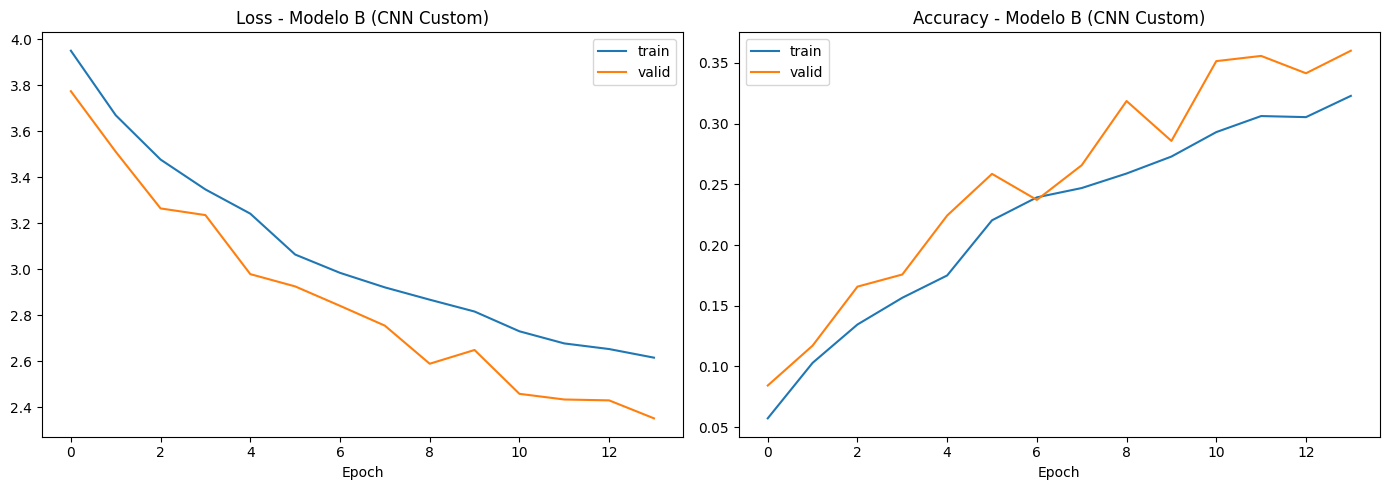

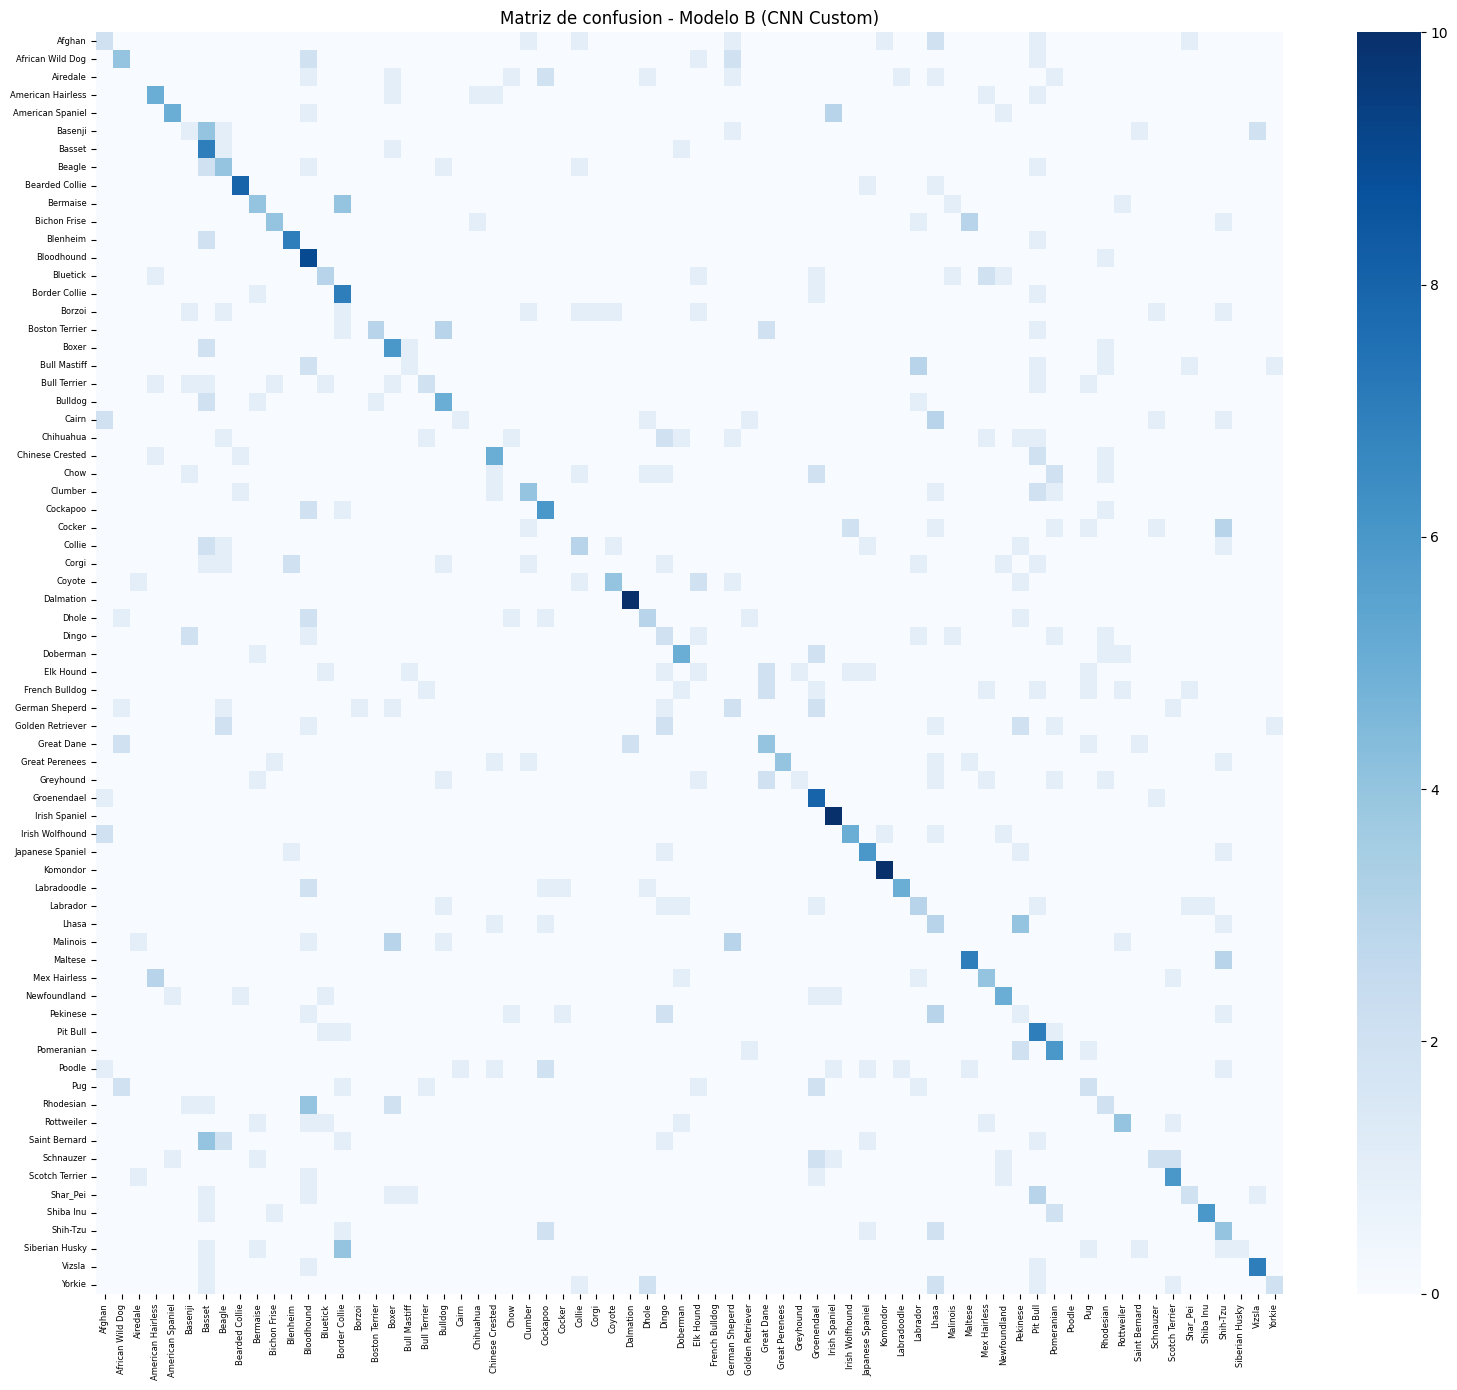

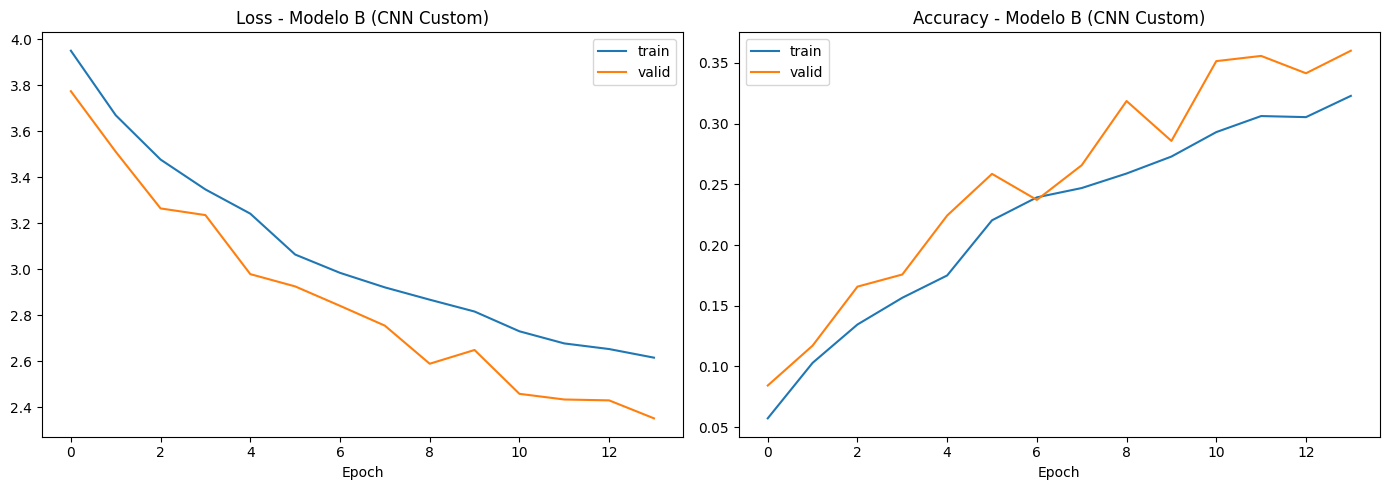

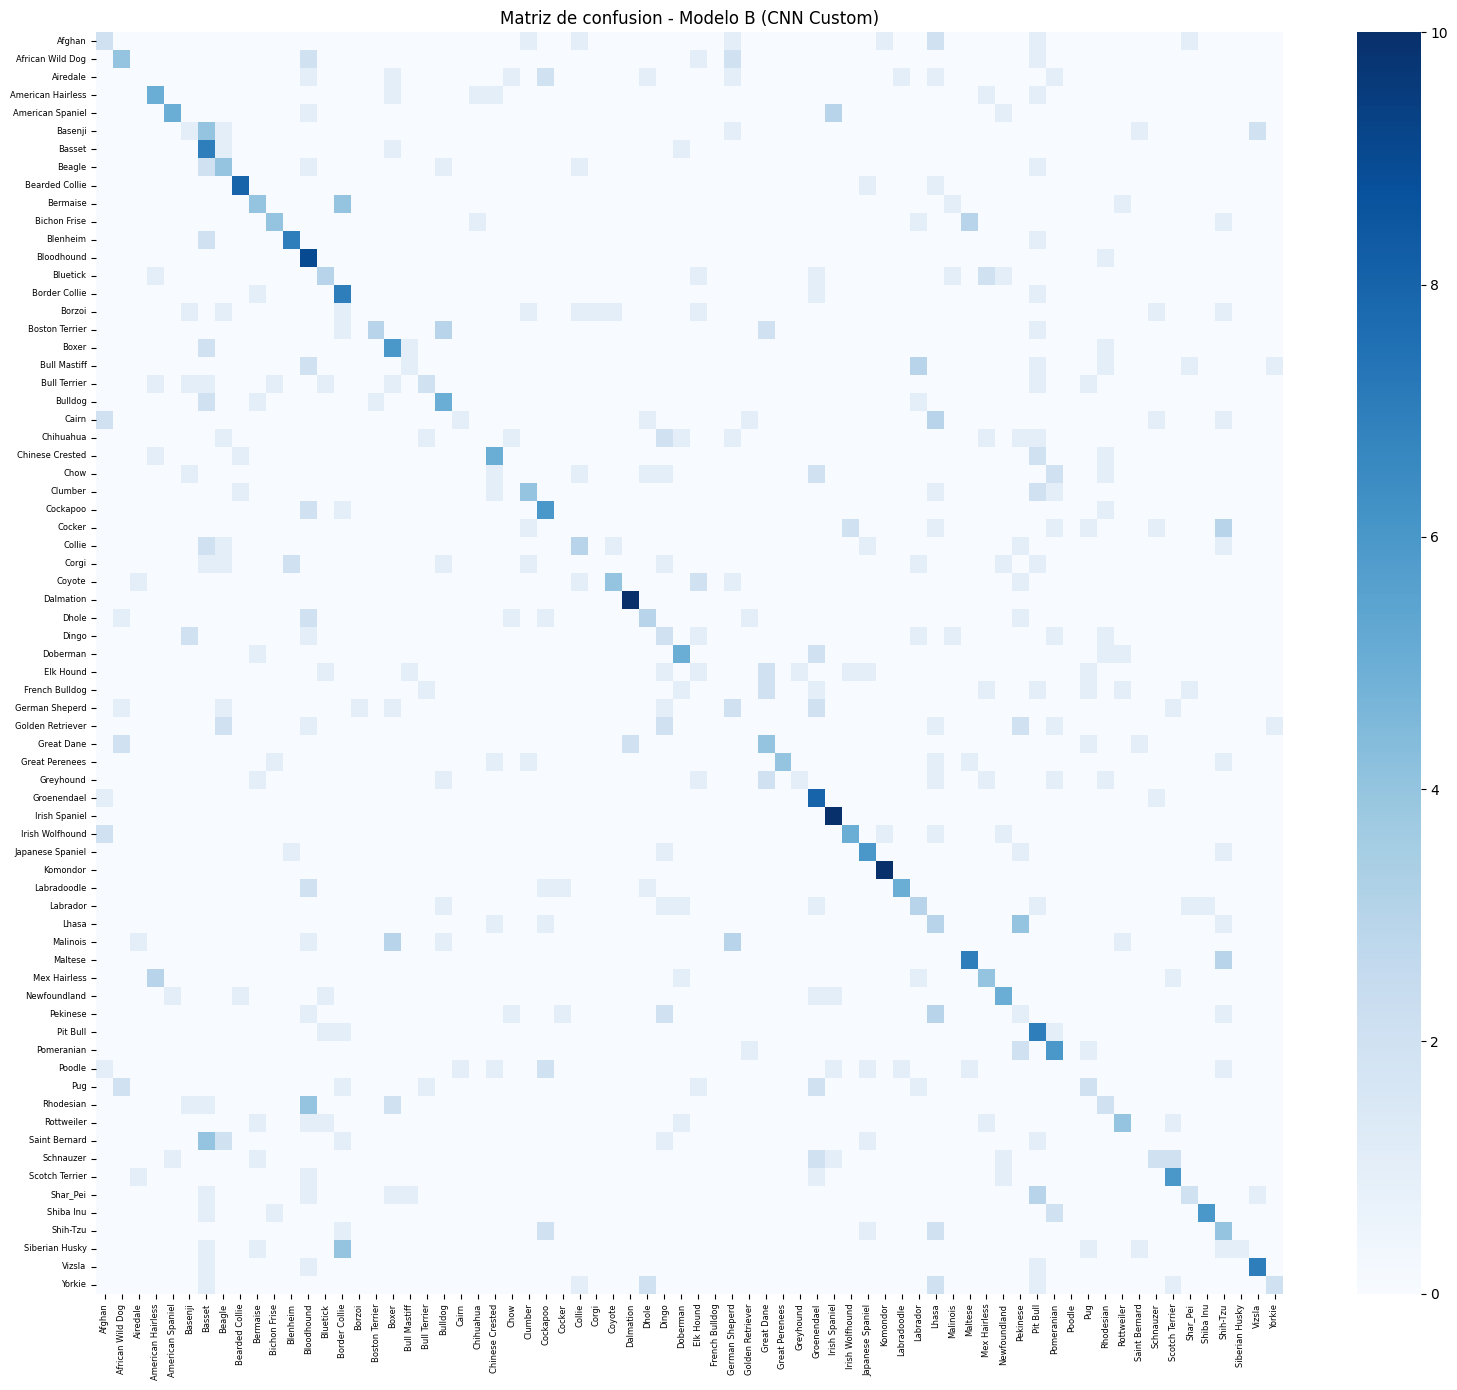

In [51]:
# Curvas de entrenamiento y matriz de confusion (Modelo B)
checkpoint_b = torch.load(classifier.checkpoints["cnn_custom"], map_location="cpu", weights_only=False)
history_b = checkpoint_b["history"]

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
axes[0].plot(history_b["train_loss"], label="train")
axes[0].plot(history_b["valid_loss"], label="valid")
axes[0].set_title("Loss - Modelo B (CNN Custom)")
axes[0].set_xlabel("Epoch")
axes[0].legend()

axes[1].plot(history_b["train_acc"], label="train")
axes[1].plot(history_b["valid_acc"], label="valid")
axes[1].set_title("Accuracy - Modelo B (CNN Custom)")
axes[1].set_xlabel("Epoch")
axes[1].legend()
plt.tight_layout()
plt.savefig("output/curves_model_b.png", dpi=100)
plt.show()

class_names_b = checkpoint_b["class_names"]
model_b = classifier._build_cnn_custom(len(class_names_b))
model_b.load_state_dict(checkpoint_b["model_state_dict"])
model_b.eval()

test_tf = classifier._build_transforms(train=False)
test_ds_b = datasets.ImageFolder(settings.dataset_path / "test", transform=test_tf)
test_loader_b = DataLoader(test_ds_b, batch_size=settings.batch_size, shuffle=False)

all_preds_b, all_labels_b = [], []
with torch.no_grad():
    for images, labels in test_loader_b:
        images = images.to(classifier.device)
        outputs = model_b(images)
        all_preds_b.extend(outputs.argmax(1).cpu().numpy())
        all_labels_b.extend(labels.numpy())

cm_b = confusion_matrix(all_labels_b, all_preds_b)
plt.figure(figsize=(16, 14))
sns.heatmap(cm_b, xticklabels=class_names_b, yticklabels=class_names_b, cmap="Blues")
plt.title("Matriz de confusion - Modelo B (CNN Custom)")
plt.xticks(rotation=90, fontsize=6)
plt.yticks(rotation=0, fontsize=6)
plt.tight_layout()
plt.savefig("output/confusion_matrix_b.png", dpi=100)
plt.show()

### Análisis Modelo B (CNN Custom)

Las curvas muestran convergencia estable pero más lenta que en Modelo A, con un leve overfitting constante, y una brecha train-valid pequeña. En la matriz de confusión, las razas con peor desempeño son
Malinois (pastor belga), que suelen confundirse con German Sheperd (pastor alemán),
lo cual es consistente con similitud visual entre razas. Pero hay más casos con errores similares, dónde la similitud visual no es tanta, por ejemplo Saint Bernard y Basset.
Comparado con el Modelo A, el Modelo B muestra
una mayor brecha train-valid, lo cual es esperable dado que no parte de pesos preentrenados.

## 9. Estudio comparativo

Se comparan ambos modelos entrenados (ResNet18 Fine-Tuned y CNN Custom) en
metricas globales, clases con peor desempeño, y trade-offs de costo
computacional vs. performance. Las conclusiones de esta seccion se
trasladan al informe (`informe.ipynb`).

In [59]:
for nombre, history in [("Modelo A", history_a), ("Modelo B", history_b)]:
    epoch_mejor_loss = int(np.argmin(history["valid_loss"]))
    epoch_mejor_acc = int(np.argmax(history["valid_acc"]))
    print(f"{nombre}: mejor valid_loss en epoch {epoch_mejor_loss} | mejor valid_acc en epoch {epoch_mejor_acc}")
    print(f"  -> {'coinciden' if epoch_mejor_loss == epoch_mejor_acc else 'NO coinciden'}")

Modelo A: mejor valid_loss en epoch 8 | mejor valid_acc en epoch 8
  -> coinciden
Modelo B: mejor valid_loss en epoch 13 | mejor valid_acc en epoch 13
  -> coinciden


In [52]:
comparison = pd.DataFrame([metrics_a, metrics_b], index=["ResNet18 Fine-Tuned", "CNN Custom"])
comparison

,accuracy,precision,recall,specificity,f1
ResNet18 Fine-Tuned,0.958571,0.960078,0.958571,0.99940,0.956634
CNN Custom,0.371429,0.370877,0.371429,0.99089,0.342359


In [54]:
def medir_tiempo_inferencia(model, device, image_size, n_iter=50):
    model.eval()
    dummy = torch.randn(1, 3, image_size, image_size).to(device)
    with torch.no_grad():
        for _ in range(5):  # warmup
            model(dummy)
        start = time.time()
        for _ in range(n_iter):
            model(dummy)
        elapsed = time.time() - start
    return (elapsed / n_iter) * 1000  # ms por inferencia

def contar_parametros(model):
    return sum(p.numel() for p in model.parameters())

tiempo_a = medir_tiempo_inferencia(model_a, classifier.device, settings.image_size)
tiempo_b = medir_tiempo_inferencia(model_b, classifier.device, settings.image_size)

tradeoffs = pd.DataFrame({
    "Modelo": ["ResNet18 Fine-Tuned", "CNN Custom"],
    "Parametros": [contar_parametros(model_a), contar_parametros(model_b)],
    "Tiempo inferencia (ms)": [tiempo_a, tiempo_b],
    "Accuracy (test)": [metrics_a["accuracy"], metrics_b["accuracy"]],
})
tradeoffs

,Modelo,Parametros,Tiempo inferencia (ms),Accuracy (test)
0,ResNet18 Fine-Tuned,11212422,2.971191,0.958571
1,CNN Custom,407366,0.667920,0.371429


### Trade-offs entre modelos
ResNet18 Fine-Tuned logra 96% de accuracy con 1.1M de parámetros y 3 ms
de inferencia, frente a 37% / 400k / 0.66 de la CNN Custom. El fine-tuning resulta preferible en
este caso

### Clases peor clasificadas:

In [ ]:
def peores_clases(cm, class_names, top_n=5):
    """
    Para cada clase, calcula recall (sensibilidad) y la cantidad de falsos
    positivos que genera en otras clases. Devuelve las top_n clases con
    peor recall, que son las que el modelo confunde mas seguido.
    """
    recalls = cm.diagonal() / cm.sum(axis=1)
    falsos_positivos = cm.sum(axis=0) - cm.diagonal()

    df = pd.DataFrame({
        "clase": class_names,
        "recall": recalls,
        "falsos_positivos": falsos_positivos,
        "n_muestras": cm.sum(axis=1),
    }).sort_values("recall")

    return df.head(top_n)

print("Modelo A - peores 5 clases por recall:")
peores_a = peores_clases(cm, class_names)
print(peores_a)

print("\nModelo B - peores 5 clases por recall:")
peores_b = peores_clases(cm_b, class_names_b)
print(peores_b)

Modelo A - peores 5 clases por recall:
               clase  recall  falsos_positivos  n_muestras
50          Malinois     0.3                 1          10
20           Bulldog     0.7                 1          10
4   American Spaniel     0.8                 1          10
7             Beagle     0.9                 1          10
24              Chow     0.9                 0          10

Modelo B - peores 5 clases por recall:
        clase  recall  falsos_positivos  n_muestras
2    Airedale     0.0                 3          10
15     Borzoi     0.0                 1          10
29      Corgi     0.0                 1          10
22  Chihuahua     0.0                 2          10
24       Chow     0.0                 4          10


In [64]:
def top_confusiones(cm, class_names, peores_df, top_n_confusiones=3):
    filas = []
    for clase in peores_df["clase"]:
        i = class_names.index(clase)
        fila = cm[i].copy()
        fila[i] = 0  # excluir la diagonal (aciertos)
        top_idx = np.argsort(fila)[::-1][:top_n_confusiones]
        confusiones = [(class_names[j], int(fila[j])) for j in top_idx if fila[j] > 0]
        filas.append({"clase": clase, "confundida_con": confusiones})
    return pd.DataFrame(filas)

print("Modelo A:")
print(top_confusiones(cm, class_names, peores_a))
print("\nModelo B:")
print(top_confusiones(cm_b, class_names_b, peores_b))

Modelo A:
              clase                                     confundida_con
0          Malinois  [(German Sheperd, 4), (Great Dane, 2), (Dingo,...
1           Bulldog         [(Boston Terrier, 2), (French Bulldog, 1)]
2  American Spaniel                               [(Irish Spaniel, 2)]
3            Beagle                                    [(Bluetick, 1)]
4              Chow                                  [(Pomeranian, 1)]

Modelo B:
       clase                                     confundida_con
0   Airedale            [(Cockapoo, 2), (Boxer, 1), (Lhasa, 1)]
1     Borzoi         [(Shih-Tzu, 1), (Clumber, 1), (Beagle, 1)]
2      Corgi        [(Blenheim, 2), (Beagle, 1), (Labrador, 1)]
3  Chihuahua     [(Dingo, 2), (Doberman, 1), (Mex Hairless, 1)]
4       Chow  [(Groenendael, 2), (Pomeranian, 2), (Rhodesian...


### Evaluacion contra el conjunto independiente (external_eval):

No se modifica evaluate_classifier(): esa funcion exige que las clases del test set coincidan exactamente con las del checkpoint (70 razas), y external_eval solo cubre un subconjunto de razas. Se define una funcion auxiliar de notebook (fuera de ClassifierService) que reutiliza _build_transforms y el modelo ya entrenado, pero calcula las metricas restringidas a las clases efectivamente presentes en external_eval.

In [55]:
def evaluar_contra_externo(classifier_service, model, external_path, class_names):
    test_tf = classifier_service._build_transforms(train=False)
    external_ds = datasets.ImageFolder(external_path, transform=test_tf)

    clases_externas = set(external_ds.classes)
    clases_checkpoint = set(class_names)
    no_reconocidas = clases_externas - clases_checkpoint
    if no_reconocidas:
        raise ValueError(
            f"El conjunto externo tiene razas que el modelo no conoce: {no_reconocidas}. "
            "Revisar normalizacion de nombres de carpeta."
        )

    external_loader = DataLoader(external_ds, batch_size=settings.batch_size, shuffle=False)

    all_preds, all_labels = [], []
    with torch.no_grad():
        for images, labels in external_loader:
            images = images.to(classifier_service.device)
            outputs = model(images)
            preds = outputs.argmax(dim=1).cpu().numpy()
            # preds ya esta en el espacio de indices del checkpoint (0..69):
            # el modelo tiene una capa de salida de 70 clases, no hay que tocar preds.
            # labels SI hay que remapearlas: vienen indexadas 0..4 segun el orden
            # alfabetico que ImageFolder le dio a external_eval, y hay que llevarlas
            # al indice real de esa raza dentro de class_names (0..69).
            labels_remapeadas = [class_names.index(external_ds.classes[l]) for l in labels.numpy()]
            all_preds.extend(preds.tolist())
            all_labels.extend(labels_remapeadas)

    all_preds = np.array(all_preds)
    all_labels = np.array(all_labels)

    labels_presentes = sorted(class_names.index(c) for c in clases_externas)

    accuracy = float((all_preds == all_labels).mean())
    precision, recall, f1, _ = precision_recall_fscore_support(
        all_labels, all_preds, labels=labels_presentes, average="macro", zero_division=0
    )

    return {
        "accuracy": accuracy,
        "precision": float(precision),
        "recall": float(recall),
        "f1": float(f1),
        "n_clases_evaluadas": len(labels_presentes),
        "n_imagenes": len(all_labels),
    }

In [56]:
class_names = checkpoint["class_names"]  # del Modelo A, ya cargado en celda 25

model_a_eval = classifier._build_resnet18_finetuned(len(class_names))
model_a_eval.load_state_dict(checkpoint["model_state_dict"])
model_a_eval.eval()

metrics_a_external = evaluar_contra_externo(classifier, model_a_eval, EXTERNAL_SET_PATH, class_names)

checkpoint_b = torch.load(classifier.checkpoints["cnn_custom"], map_location="cpu", weights_only=False)
model_b_eval = classifier._build_cnn_custom(len(class_names))
model_b_eval.load_state_dict(checkpoint_b["model_state_dict"])
model_b_eval.eval()

metrics_b_external = evaluar_contra_externo(classifier, model_b_eval, EXTERNAL_SET_PATH, class_names)

comparison_external = pd.DataFrame(
    [metrics_a_external, metrics_b_external],
    index=["ResNet18 Fine-Tuned (external)", "CNN Custom (external)"],
)
comparison_external

,accuracy,precision,recall,f1,n_clases_evaluadas,n_imagenes
ResNet18 Fine-Tuned (external),0.538462,1.0,0.533333,0.655238,5,26
CNN Custom (external),0.153846,0.4,0.140000,0.200000,5,26


## 10. Descargar los checkpoints

Descargalos y colocalos en `models/` de tu entorno local para que la aplicacion los use
(pestañas Etapa 1 y 2 del frontend). Recorda publicarlos en un link de solo lectura publico.

In [57]:
!ls -lh models/

try:
    from google.colab import files

    files.download(str(settings.model_path / settings.resnet18_model_name))
    # files.download(str(settings.model_path / settings.cnn_custom_model_name))
except ImportError:
    print("Fuera de Colab: los checkpoints quedan en models/")

total 0


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>